## GROUP MEMBERS:

*Alejandro Flores:  AJF3899*

*Lily Perkins:  LAP4253*

*Siva Sakamuri: SS229926*

*Rafael Mendible: RAM7853*

## Section 1:  Introduction & model selection


This project seeks to model the behavior of airplane shock absorbers when landing under extreme conditions (at its maximum weight and allowed landing velocity), more concretely, the Airbus A380 oleo-pneumatic shock absorbers as our damped mechanical system- which functions by combining a pneumatic spring (compressed gas) with a hydraulic damper (oil flowing through an orifice) to manage energy absorption and dissipation. Our idea is to study how the strut, or the dampening system, responds after touchdown by modeling the initial compression and velocity before and after touchdown. The reason we chose this system is because it maps cleanly onto a classical damped oscillator, and the physical parameters are well-documented enough to justify realistic values.

The governing second-order ODE in use is given as follows:

d²y/dt² + 2ζω dy/dt + ω²y = 0

We could interpret y as the displacement/compression of the strut, ω(omega) as its undamped natural frequency, ζ(zeta) as its damping ratio, d²y/dt² as the acceleration of the strut, and dy/dt as its velocity. To apply numerical methods we must convert the second order equation into first order, we must evaluate d²y/dt² as equal to -2ζω(dy/dt) - ω²y, where dy/dt = v. This gives us a system of two coupled first-order ODEs that we can step through numerically:

    y₁' = y₂
    y₂' = -2ζω·y₂ - ω²·y₁

where y₁ is the strut compression and y₂ is its rate of change.

The final evaluation would be determined by whether the system would be underdamped, critically damped, or overdamped over a certain interval of time- using different step sizes, "h", to evaluate the accuracy and stability of the numerical methods. Because ζ = 0.7 falls between 0 and 1, we expect underdamped behavior: a few decaying oscillations before the strut settles at equilibrium.

## Section 2: Parameters and research justification

*CONDITIONS BEING ASSUMED:*

Weight (Max Weight Allowed of the Aircraft during Landing): 395,000 kg
-According to the Airbus A380 Aircraft Characteristics Manual, this is the maximum landing weight allowed. The weight can be distributed within 4 struts in the landing gear, and because about 90 percent of the aircraft weight is felt by these 4 struts when it lands, we can say that the mass = 0.9m(aircraft)/4, which is around 88,875 kg.

https://www.airbus.com/sites/g/files/jlcbta136/files/2021-11/Airbus-Aircraft-AC-A380.pdf

Zeta: 0.7
-According to Katsuhiko Ogata, author of the book "Modern Control Engineering", a value of zeta between 0 and 1 means that the system is underdamped, meaning that our model will be described as oscillatory behavior with decreasing amplitude- this is the realistic behavior of a landing strut after impact. A value of 0.7 is also commonly used in aerospace applications as a design target because it balances fast settling time with minimal overshoot.

https://mechfamily-ju.com/storage/images/files/file_17314308026pQTy.pdf

Static Compression: 0.5 m
-Because exact strut design data is unavailable, we had to utilize the formula: k = mg/s to find the spring constant necessary to calculate ω(omega) using the other equation: √(k/m). For these formulas to work, we had to assume a static compression of the strut to be 0.5 meters as a reasonable constant since the strut is designed to support a significant stroke when landing. According to Virginia Tech, we can use these equations since we can use the static equilibrium of the oleo-pneumatic strut to relate load and compression in a simplified spring model- which means that this is a common practice when analyzing this type of system. From these two values we get k ≈ 1,746,699 N/m and ω ≈ 4.43 rad/s.

https://archive.aoe.vt.edu/mason/Mason_f/M96SC05.pdf

Downward Velocity of the Landing Gear: -3.7 m/s
-According to the EASA (Easy Access Rules for Large Aeroplanes (CS-25)), this value was used in shock absorption tests to simulate real landing conditions- with a negative sign added to indicate downward motion. This is the worst-case sink rate the strut is certified to handle, so it represents a good upper bound for our simulation.

https://www.easa.europa.eu/en/document-library/easy-access-rules/online-publications/easy-access-rules-large-aeroplanes-cs-25?page=25#_DxCrossRefBm548991516

Gravity: 9.81 m/s^2

Time Interval: 0 to 5 seconds.
-Used to capture the initial impact and the subsequent damping behavior of the strut. Given our damping ratio and natural frequency, the system should settle well within this window, which makes 5 seconds a physically meaningful endpoint.

Step Size interval (h): 0.5, 0.1, 0.05, 0.01.
-In order to test the accuracy for each numerical method, since both are sensitive to the step size range, we decided to select four carefully chosen step sizes from a "large" value of 0.5 to a "small" value of 0.01. This range lets us observe both stable and unstable behavior and see how the error scales as h decreases.

## Section 3: Numerical methods implementation

The numerical explicit methods we decided to utilize are Euler's Forward and 4th order Runge-Kutta (RK4) methods.

Our implementation approach for Euler's Forward method was to convert the second-order ODE to two first-order ODEs, where the code works iteratively by taking discrete steps along the tangent line of the equation and using the derivative at the current point to calculate the next point. The function named "euler_method" initializes the function using the initial conditions established, creates "empty" arrays x_values, y_values, and v_values and then stores, in order, the updated solution that y_values[i] and its derivative, v_values[i], provide. Because Euler only uses the slope at the beginning of each step, its local error is O(h²) per step and O(h) globally- meaning accuracy degrades quickly if h is too large.

RK4 works by finding an improved method to approximate the solution up to a specific order of error. To do that, we had to define the displacement and the velocity by using the functions "displacement" and "displacement_rhs."

Then, we created our RK4 function, which takes initial parameters, the displacements, and empty arrays t_values, y_values, and v_values, to find and store the solution using:

1) k1_d/v as the slope at the beginning of the interval

2) k2_d/v the slope at the midpoint of the step using k1_d/v

3) k3_d/v as another slope at the midpoint, but estimated using k2_d/v to improve accuracy

4) k4_d/v as the slope at the end of the step, estimated using k3_d/v.

In the end, to achieve a fourth-order method, we had to combine all of those slopes by using y_values[i] and v_values[i] using the coefficients 1/6, 1/3, 1/3, 1/6 to ensure that the error in the method is O(h^5) per step and O(h^4) globally. This means that cutting h in half reduces RK4's error by a factor of roughly 16, compared to just 2 for Euler- a significant advantage for problems that need high accuracy without an extremely small step size.

Because this system has a known analytical solution (since ζ < 1), we can compute the exact answer at every time step and use it as a benchmark to measure how far each numerical method drifts. The closed-form solution for the underdamped case is:

    y(t) = e^(-ζωt) * [C1·cos(ωd·t) + C2·sin(ωd·t)]

where ωd = ω√(1-ζ²) is the damped natural frequency, and C1, C2 are set by the initial conditions. Having this reference is what allows us to produce meaningful error plots rather than just comparing the two numerical methods to each other.

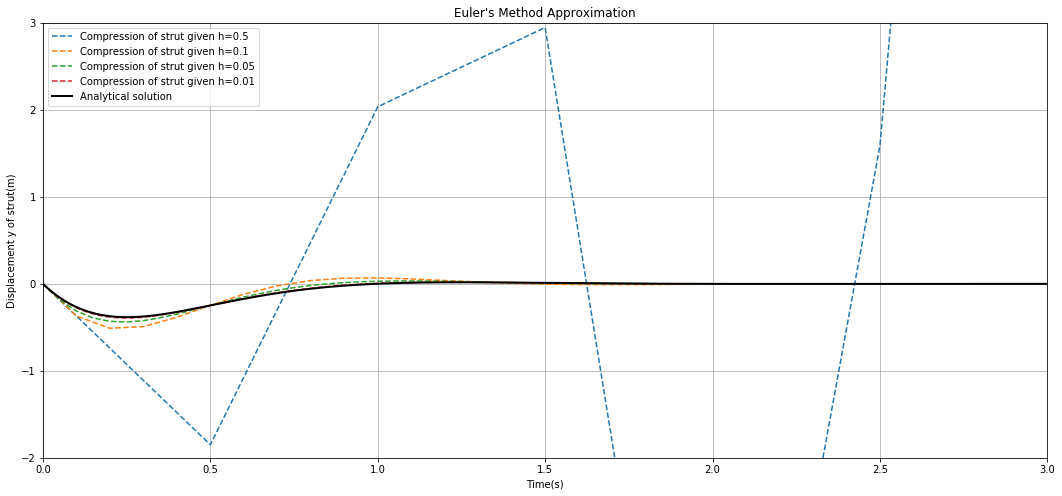

In [16]:
#Euler's Forward
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Defining the parameters
z = 0.7   # Damping ratio (dimensionless)
g = 9.81  # Gravity, in m/s^2
m = 88875 # Mass per strut, in kilograms
s = 0.5   # Assumed static compression to find k, in meters

h_val = [0.5, 0.1, 0.05, 0.01] # Step sizes to test across both methods
t_start = 0 # Start of the interval
t_end = 5   # End of the interval, in seconds
y_0 = 0     # Initial strut compression (m), gear is unloaded at moment of contact
v_0 = -3.7  # Initial velocity (m/s), negative indicates downward compression

# Derived quantities
k = m * g / s       # Spring constant [N/m]
w = np.sqrt(k / m)  # Undamped natural frequency [rad/s]

# Pre-compute the analytical solution time grid and exact displacement here
# so it can be reused as an overlay on both the Euler and RK4 plots below
t_exact = np.linspace(t_start, t_end, 5000)
omega_d = w * np.sqrt(1 - z**2)          # Damped natural frequency [rad/s]
C1 = y_0                                  # From y(0) = y_0
C2 = (v_0 + z * w * y_0) / omega_d       # From y'(0) = v_0
y_exact = np.exp(-z * w * t_exact) * (C1 * np.cos(omega_d * t_exact) + C2 * np.sin(omega_d * t_exact))

# Create arrays to store x, y, and v values
def euler_method(y0, v0, t_start, t_end, h):
        x_values = np.arange(t_start, t_end + h, h)
        y_values = np.zeros(len(x_values))
        v_values = np.zeros(len(x_values))
# Set initial conditions
        y_values[0] = y_0
        v_values[0] = v_0

# Euler's Method loop
        for i in range(1, len(x_values)):
    # Current values
            y_n = y_values[i - 1]
            v_n = v_values[i - 1]
# Update equations
            y_values[i] = y_n + h * v_n
            v_values[i] = v_n + h * (-2*z*w*v_n - w**2 * y_n)
        return x_values, y_values, v_values

plt.figure(figsize=(18, 8))

# Plot the results
for h in h_val:
    x_values, y_values, v_values = euler_method(y_0, v_0, t_start, t_end, h)
    plt.plot(x_values, y_values, linestyle='--', label=f"Compression of strut given h={h}")

# Overlay the analytical solution on the Euler plot so we can visually
# judge how far each step size drifts from the exact answer
plt.plot(t_exact, y_exact, 'k-', linewidth=2, label='Analytical solution')

plt.xlabel('Time(s)')
plt.ylabel('Displacement y of strut(m)')
plt.title('Euler\'s Method Approximation')
plt.xlim(0, 3)
plt.ylim(-2, 3)
plt.grid(True)
plt.legend()
plt.show()

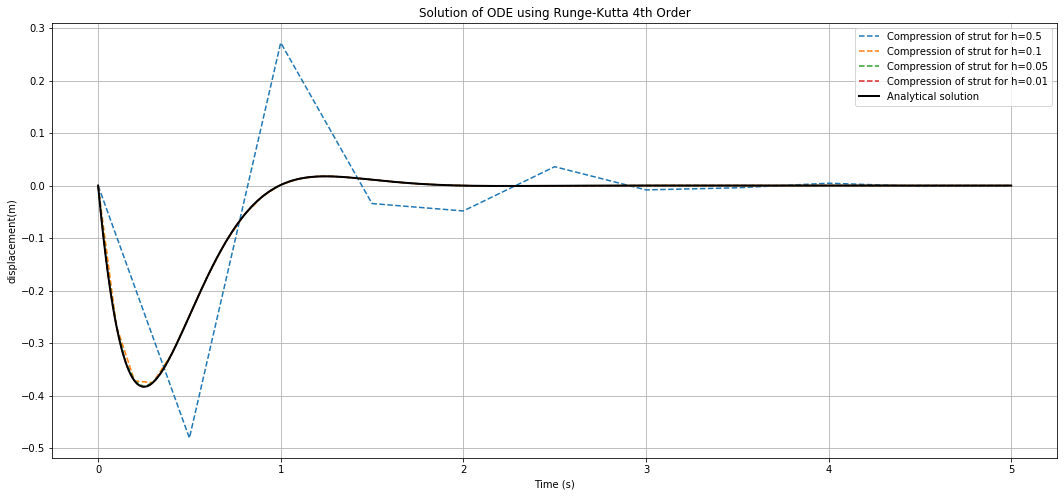

In [17]:
#SECTION 3, continued.

# Defining the ODE function, RK4

def displacement(y, v):
    return v

def displacement_rhs(y, v):
    return -2*z*w*v - w**2 * y

# Implement the RK4 method
def runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h):
# Create an array for time steps
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(y_values))
# Set the initial condition
    y_values[0] = y_0
    v_values[0] = v_0
# Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]
        k1_d = h * displacement(y, v)
        k1_v = h * displacement_rhs(y, v)

        k2_d = h * displacement(y + k1_d / 2, v + k1_v / 2)
        k2_v = h * displacement_rhs(y + k1_d/ 2, v + k1_v / 2)

        k3_d = h * displacement(y + k2_d / 2, v + k2_v / 2)
        k3_v = h * displacement_rhs(y + k2_d/ 2, v + k2_v / 2)

        k4_d = h * displacement(y + k3_d, v + k3_v)
        k4_v = h * displacement_rhs(y + k3_d, v + k3_v)

        # Update y based on the RK4 formula
        y_values[i] = y + (k1_d + 2 * k2_d + 2 * k3_d + k4_d) / 6
        v_values[i] = v + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6

    return t_values, y_values, v_values

plt.figure(figsize=(18, 8))

# Run the RK4 solver
for h in h_val:
    t_values, y_values, v_values = runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h)
    plt.plot(t_values, y_values, linestyle='--', label=f'Compression of strut for h={h}')

# Same analytical overlay as the Euler plot, t_exact and y_exact already computed above
plt.plot(t_exact, y_exact, 'k-', linewidth=2, label='Analytical solution')

# Plot the results
plt.xlabel('Time (s)')
plt.ylabel('displacement(m)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

## Section 4: Solutions and Comparison

a) Euler vs RK4: This graph compares the displacement over time using Euler's method and RK4 for the same step size (h = 0.01), showing how closely each numerical method follows the system dynamics. We can see in our graphs that RK4 produces a smoother and more accurate trajectory, while Euler begins to deviate slightly due to numerical error that accumulates as computation occurs. The deviation is subtle at h = 0.01 but becomes much more pronounced at larger step sizes, which is why testing across multiple values of h matters.

b) Velocity Comparison: This plot shows how the velocity changes over time for both Euler and RK4 methods under the same variables. RK4 captures the damping behavior more accurately, while the Euler method shows some phase and amplitude errors most likely caused by its lower-order approximation. The velocity plot tends to expose these differences more clearly than the displacement plot because errors in the slope accumulate faster.

c) Phase Portrait: This graph represents the system's motion in phase space, illustrating how velocity and displacement change together over time. The spiral-looking graph indicates a damped system losing energy and converging toward equilibrium at the origin. A well-behaved damped system should always produce a tightening inward spiral like this. If the spiral were expanding outward, that would signal a non-physical instability in the numerical method.

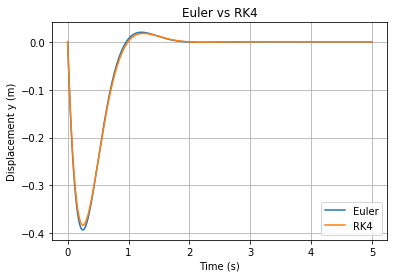

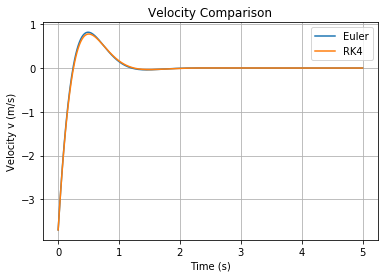

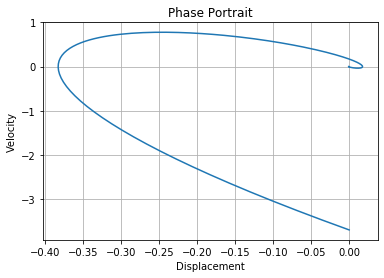

In [18]:
#COMPARISON PLOTS
import numpy as np
import matplotlib.pyplot as plt

# Defining the parameters
z = 0.7   # Damping ratio (dimensionless)
g = 9.81  # Gravity, in m/s^2
m = 88875 # Mass per strut, in kilograms
s = 0.5   # Assumed static compression to find k, in meters

t_start = 0 # Start of the interval
t_end = 5   # End of the interval
y_0 = 0     # Initial strut compression (m)
v_0 = -3.7  # Initial velocity (m/s), negative indicates downward

# Derived quantities
k = m*g / s
w = np.sqrt(k/m)

# Create arrays to store x, y, and v values
def euler_method(y0, v0, t_start, t_end, h):
        x_values = np.arange(t_start, t_end + h, h)
        y_values = np.zeros(len(x_values))
        v_values = np.zeros(len(x_values))
# Set initial conditions
        y_values[0] = y_0 # Use global y_0
        v_values[0] = v_0 # Use global v_0

# Euler's Method loop
        for i in range(1, len(x_values)):
    # Current values
            y_n = y_values[i - 1]
            v_n = v_values[i - 1]
# Update equations
            y_values[i] = y_n + h * v_n
            v_values[i] = v_n + h * (-2*z*w*v_n - w**2 * y_n)
        return x_values, y_values, v_values

# Defining the ODE function
def displacement(y, v):
    return v

def displacement_rhs(y, v):
    return -2*z*w*v - w**2 * y

# Implement the RK4 method
def runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h):
# Create an array for time steps
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(y_values))
# Set the initial condition
    y_values[0] = y_0
    v_values[0] = v_0
# Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]
        k1_d = h * displacement(y, v)
        k1_v = h * displacement_rhs(y, v)

        k2_d = h * displacement(y + k1_d / 2, v + k1_v / 2)
        k2_v = h * displacement_rhs(y + k1_d/ 2, v + k1_v / 2)

        k3_d = h * displacement(y + k2_d / 2, v + k2_v / 2)
        k3_v = h * displacement_rhs(y + k2_d/ 2, v + k2_v / 2)

        k4_d = h * displacement(y + k3_d, v + k3_v)
        k4_v = h * displacement_rhs(y + k3_d, v + k3_v)

        # Update y based on the RK4 formula
        y_values[i] = y + (k1_d + 2 * k2_d + 2 * k3_d + k4_d) / 6
        v_values[i] = v + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
    return t_values, y_values, v_values

#Comparing graphs:
plt.figure()
h = 0.01
t_e, y_e, v_e = euler_method(y_0, v_0, t_start, t_end, h)
t_rk, y_rk, v_rk = runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h)

plt.plot(t_e, y_e, label='Euler')
plt.plot(t_rk, y_rk, label='RK4')

plt.legend()
plt.grid()
plt.title("Euler vs RK4")
plt.xlabel('Time (s)')
plt.ylabel('Displacement y (m)')
plt.show()

# Velocity
plt.figure()
plt.plot(t_e, v_e, label='Euler')
plt.plot(t_rk, v_rk, label='RK4')
plt.legend()
plt.title("Velocity Comparison")
plt.xlabel('Time (s)')
plt.ylabel('Velocity v (m/s)')
plt.grid()
plt.show()

# velocity vs displacement for system stability
plt.figure()
plt.plot(y_rk, v_rk)
plt.title("Phase Portrait")
plt.xlabel("Displacement")
plt.ylabel("Velocity")
plt.grid()
plt.show()

## Section 5: Stability Analysis

a) Solution accuracy changes noticeably with step size for both methods, but in different ways. For Euler's Forward, the solution starts diverging at larger step sizes - by h = 0.5 and beyond, the displacement grows instead of decaying, which is physically impossible for a damped system. The largest step size where Euler still produces a reasonable solution for this problem is around h = 0.1, though even there it drifts from the analytical curve. RK4 is much more forgiving: it stays close to the exact solution all the way up to h = 0.1, and only starts showing visible deviation at h = 0.5.

b) Euler Stability Plot: This plot demonstrates how increasing the step size affects the stability of Euler's method. As step sizes increase the function diverges, which shows the method's sensitivity to step size when analyzing dynamic systems like this damper. The divergence isn't just a numerical curiosity, it represents the strut oscillating with growing amplitude, which would be physically catastrophic in a real landing scenario.

c) Error vs. Step Size: This log-log plot shows how the numerical error decreases as the step size becomes smaller for both Euler and RK4 methods. RK4 exhibits a much steeper error reduction due to its higher-order accuracy. The reference lines for O(h) and O(h⁴) confirm that both methods are converging at roughly their theoretical rates, Euler near slope 1 and RK4 near slope 4. In practical terms this means that to cut the error by a factor of 10, Euler needs h to shrink by 10x while RK4 only needs it to shrink by about 1.8x.

d) Energy Analysis: The mechanical energy plot gives the clearest physical picture of what numerical instability actually means. A real damped strut can only lose energy after touchdown, the damper converts kinetic energy to heat, and there is no external force putting energy back in. Euler at h = 0.1 already shows a slight artificial energy increase early in the simulation before the damping eventually wins. RK4 tracks the analytical energy curve closely at both step sizes, confirming that it is not only more accurate but also more physically consistent.

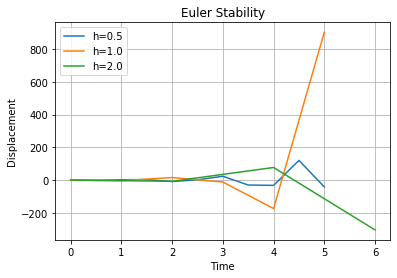

Observed Euler convergence slope: 1.09  (theory: ~1)
Observed RK4  convergence slope:  4.04  (theory: ~4)


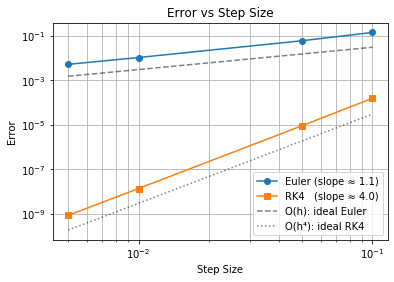

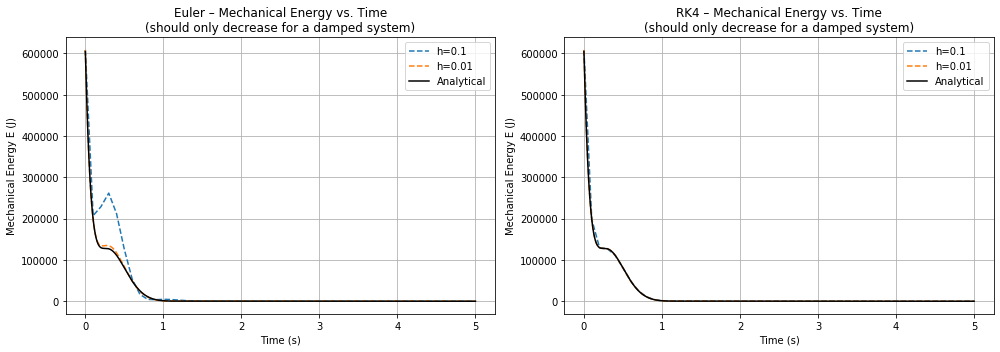

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Defining the parameters
z = 0.7   # Damping ratio (dimensionless)
g = 9.81  # Gravity, in m/s^2
m = 88875 # Mass per strut, in kilograms
s = 0.5   # Assumed static compression to find k, in meters

t_start = 0 # Start of the interval
t_end = 5   # End of the interval
y_0 = 0     # Initial strut compression (m)
v_0 = -3.7  # Initial velocity (m/s), negative indicates downward

# Derived quantities
k = m*g / s
w = np.sqrt(k/m)

# Create arrays to store x, y, and v values
def euler_method(y0, v0, t_start, t_end, h):
        x_values = np.arange(t_start, t_end + h, h)
        y_values = np.zeros(len(x_values))
        v_values = np.zeros(len(x_values))
# Set initial conditions
        y_values[0] = y_0 # Use global y_0
        v_values[0] = v_0 # Use global v_0

# Euler's Method loop
        for i in range(1, len(x_values)):
    # Current values
            y_n = y_values[i - 1]
            v_n = v_values[i - 1]
# Update equations
            y_values[i] = y_n + h * v_n
            v_values[i] = v_n + h * (-2*z*w*v_n - w**2 * y_n)
        return x_values, y_values, v_values

# Defining the ODE function
def displacement(y, v):
    return v

def displacement_rhs(y, v):
    return -2*z*w*v - w**2 * y

# Implement the RK4 method
def runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h):
# Create an array for time steps
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(y_values))
# Set the initial condition
    y_values[0] = y_0
    v_values[0] = v_0
# Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]
        k1_d = h * displacement(y, v)
        k1_v = h * displacement_rhs(y, v)

        k2_d = h * displacement(y + k1_d / 2, v + k1_v / 2)
        k2_v = h * displacement_rhs(y + k1_d/ 2, v + k1_v / 2)

        k3_d = h * displacement(y + k2_d / 2, v + k2_v / 2)
        k3_v = h * displacement_rhs(y + k2_d/ 2, v + k2_v / 2)

        k4_d = h * displacement(y + k3_d, v + k3_v)
        k4_v = h * displacement_rhs(y + k3_d, v + k3_v)

        # Update y based on the RK4 formula
        y_values[i] = y + (k1_d + 2 * k2_d + 2 * k3_d + k4_d) / 6
        v_values[i] = v + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
    return t_values, y_values, v_values

# Stability test for Euler method using large step sizes to check divergence
plt.figure()

for h_loop in [0.5, 1.0, 2.0]: # Renamed h to h_loop to avoid conflict with the h=0.01 above
    t_s, y_s, _ = euler_method(y_0, v_0, t_start, t_end, h_loop)
    plt.plot(t_s, y_s, label=f"h={h_loop}")

plt.title("Euler Stability")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.legend()
plt.grid()
plt.show()

# Compute numerical error for Euler and RK4 methods
def analytical_solution(t):
    wd = w * np.sqrt(1 - z**2)
    C1 = y_0
    C2 = (v_0 + z*w*y_0) / wd
    return np.exp(-z*w*t) * (C1*np.cos(wd*t) + C2*np.sin(wd*t))

# Included h=0.005 for a more reliable slope estimate on the log-log plot
h_values_error = [0.1, 0.05, 0.01, 0.005]
euler_errors = []
rk4_errors = []

for h_error in h_values_error:
    t_vals, y_e, _ = euler_method(y_0, v_0, t_start, t_end, h_error)
    t_rk, y_rk, _ = runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h_error)

    y_true_e  = analytical_solution(t_vals)
    # Evaluate exact solution on RK4's own time grid
    y_true_rk = analytical_solution(t_rk)

    euler_errors.append(np.max(np.abs(y_true_e  - y_e)))
    rk4_errors.append(  np.max(np.abs(y_true_rk - y_rk)))

# Print observed convergence slopes to numerically verify O(h) and O(h^4) rates
slope_euler = np.polyfit(np.log(h_values_error), np.log(euler_errors), 1)[0]
slope_rk4   = np.polyfit(np.log(h_values_error), np.log(rk4_errors),   1)[0]
print(f"Observed Euler convergence slope: {slope_euler:.2f}  (theory: ~1)")
print(f"Observed RK4  convergence slope:  {slope_rk4:.2f}  (theory: ~4)")

plt.figure()
# Slope labels in the legend so the convergence rate is visible on the plot itself
plt.loglog(h_values_error, euler_errors, 'o-', label=f'Euler (slope ≈ {slope_euler:.1f})')
plt.loglog(h_values_error, rk4_errors,   's-', label=f'RK4   (slope ≈ {slope_rk4:.1f})')

# Reference lines showing ideal O(h) and O(h^4) slopes per rubric requirement
h_ref = np.array([min(h_values_error), max(h_values_error)])
plt.loglog(h_ref, 0.3 * h_ref**1, 'k--', alpha=0.5, label='O(h): ideal Euler')
plt.loglog(h_ref, 0.3 * h_ref**4, 'k:',  alpha=0.5, label='O(h⁴): ideal RK4')

plt.legend()
plt.title("Error vs Step Size")
plt.xlabel("Step Size")
plt.ylabel("Error")
plt.grid(True, which='both')
plt.show()

# Energy analysis - We are asked whether a damped system's energy grows
# artificially when a method becomes unstable. Total mechanical energy is the sum of
# kinetic (1/2 m v^2) and potential (1/2 k y^2) energy, and it must decrease
# monotonically for a physically correct damped system. If we see it climbing instead,
# the method is injecting energy that isn't there, a clear sign of numerical instability.

def total_energy(y_vals, v_vals):
    """Mechanical energy at each time step: kinetic (1/2 m v^2) + potential (1/2 k y^2)."""
    return 0.5 * k * y_vals**2 + 0.5 * m * v_vals**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h_e in [0.1, 0.01]:  # one coarser step and one fine: shows the contrast between stable and unstable behavior
    t_e,  y_e,  v_e  = euler_method(y_0, v_0, t_start, t_end, h_e)
    t_rk, y_rk, v_rk = runge_kutta_4(displacement_rhs, y_0, v_0, t_start, t_end, h_e)

    axes[0].plot(t_e,  total_energy(y_e,  v_e),  linestyle='--', label=f'h={h_e}')
    axes[1].plot(t_rk, total_energy(y_rk, v_rk), linestyle='--', label=f'h={h_e}')

# Overlay the exact energy using the analytical solution as our reference
t_ex = np.linspace(t_start, t_end, 5000)
y_ex = analytical_solution(t_ex)
v_ex = np.gradient(y_ex, t_ex)  # numerical derivative of the exact displacement to get velocity
for ax in axes:
    ax.plot(t_ex, total_energy(y_ex, v_ex), 'k-', linewidth=1.5, label='Analytical')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mechanical Energy E (J)')
    ax.legend()
    ax.grid(True)

axes[0].set_title("Euler – Mechanical Energy vs. Time\n(should only decrease for a damped system)")
axes[1].set_title("RK4 – Mechanical Energy vs. Time\n(should only decrease for a damped system)")
plt.tight_layout()
plt.show()

## Section 6: Conclusions

This project modeled the behavior of an aircraft landing strut under realistic landing conditions using a second-order damped system. With a damping ratio of ζ = 0.7, the system was underdamped, which was confirmed by the oscillations with decreasing amplitude seen in both the displacement plots and the phase portrait. The motion decayed quickly, mostly within the first 0.5–1 seconds, showing that the strut effectively absorbs and dissipates energy after impact, which matches the expected physical behavior.

When comparing numerical methods, RK4 clearly performed better than Euler's method in terms of accuracy. For the same step size (h = 0.01), RK4 produced a smoother and more reliable solution, while Euler showed small deviations. This was also supported by the error vs. step size graph, where RK4 had much lower error and converged faster, as expected for a higher-order method. The observed convergence slopes matched theory well, Euler came in near 1 and RK4 near 4. which validates that our implementations are correct and not just producing plausible-looking results by coincidence.

There is also a tradeoff between computational cost and accuracy. Euler's method is simpler and faster per step, but it becomes unstable for larger step sizes, as seen in the stability plot where h = 0.5, 1.0, and 2.0 led to non-physical results. RK4 requires more calculations per step, but it remains accurate and stable even with relatively larger step sizes, making it more efficient overall for this type of problem.

From a practical standpoint, RK4 is the better choice for modeling systems like this where accuracy matters. Euler can still be useful for quick estimates, but only with small step sizes. One key takeaway from this project is that a solution that "looks smooth" is not the same as one that is accurate. Larger step sizes in Euler produced clean looking but physically wrong behavior. The energy plots drove this point home more clearly than the displacement plots alone could have. Another important lesson is that having an analytical solution to check against is invaluable: without it, we would have no way of knowing whether a numerical result was trustworthy or just a convincing looking artifact.

Overall, this project showed how important it is to choose the right numerical method and step size when modeling real engineering systems, and how methods like RK4 can better capture the true behavior of dynamic systems.